## Import Libraries



In [3]:
# ---------------------------------------------------------------
# System & general utilities
# ---------------------------------------------------------------
import os
import gc
import glob
import time
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------
# Data science stack
# ---------------------------------------------------------------
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# Audio processing
# ---------------------------------------------------------------
import librosa
import librosa.display

# ---------------------------------------------------------------
# Image processing / plotting
# ---------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# ---------------------------------------------------------------
# TensorFlow / Keras
# ---------------------------------------------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ---------------------------------------------------------------
# Scikit-learn: splitting, encoding, evaluation
# ---------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

# ---------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Environment Information


In [5]:
print("=" * 70)
print("ENVIRONMENT INFORMATION")
print("=" * 70)
print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version       : {keras.__version__}")
print(f"NumPy version        : {np.__version__}")
print(f"librosa version      : {librosa.__version__}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) detected      : {len(gpus)} -> memory growth enabled")
    except RuntimeError as e:
        print("GPU memory growth configuration error:", e)
else:
    print("GPU(s) detected      : None -> running on CPU")
print("=" * 70)


ENVIRONMENT INFORMATION
TensorFlow version : 2.10.0
Keras version       : 2.10.0
NumPy version        : 1.23.5
librosa version      : 0.10.1
GPU(s) detected      : 1 -> memory growth enabled


## Dataset Description


In [6]:
# ---------------------------------------------------------------
# Root paths (edit ROOT_DIR only if the dataset is relocated)
# ---------------------------------------------------------------
ROOT_DIR = r"D:\MULTIMODAL DATA FUSION"

FACIAL_DIR = os.path.join(ROOT_DIR, "Facial")
FACIAL_TRAIN_DIR = os.path.join(FACIAL_DIR, "train")
FACIAL_TEST_DIR = os.path.join(FACIAL_DIR, "test")

AUDIO_DIR = os.path.join(ROOT_DIR, "Audio_Dataset")

EMOTION_CLASSES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
AUDIO_CLASSES = ["Normal", "Depression"]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Facial train directory :", FACIAL_TRAIN_DIR)
print("Facial test directory  :", FACIAL_TEST_DIR)
print("Audio directory        :", AUDIO_DIR)


Facial train directory : D:\MULTIMODAL DATA FUSION\Facial\train
Facial test directory  : D:\MULTIMODAL DATA FUSION\Facial\test
Audio directory        : D:\MULTIMODAL DATA FUSION\Audio_Dataset


## Dataset Folder Structure


Facial TRAIN class distribution:
  angry     : 3995
  disgust   : 436
  fear      : 4097
  happy     : 7215
  neutral   : 4965
  sad       : 4830
  surprise  : 3171

Facial TEST class distribution:
  angry     : 958
  disgust   : 111
  fear      : 1024
  happy     : 1774
  neutral   : 1233
  sad       : 1247
  surprise  : 831


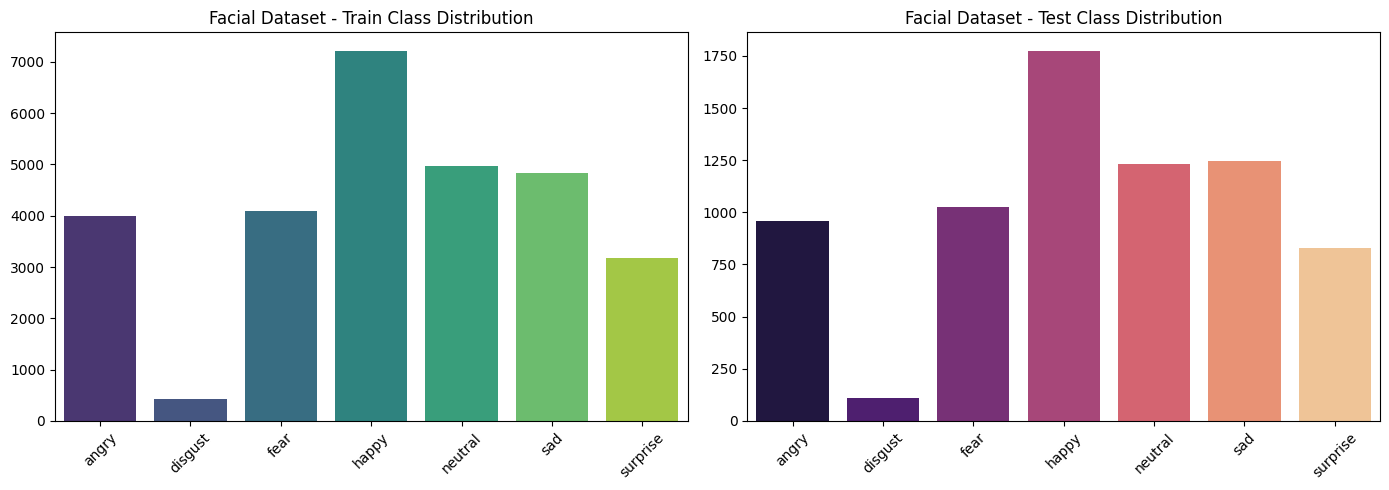


Total audio files found: 400
label
Depression    200
Normal        200
Name: count, dtype: int64


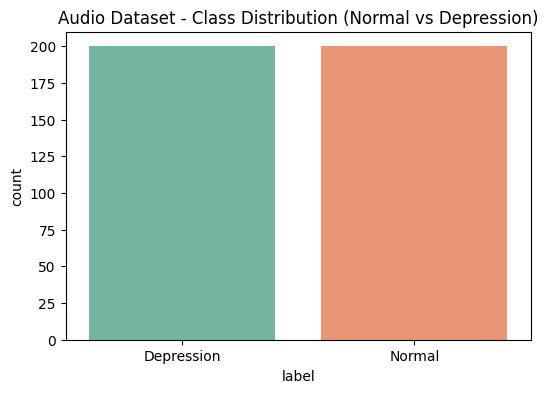

In [7]:
def count_images_per_class(base_dir, classes):
    '''Recursively count JPG/PNG images per class folder.'''
    counts = {}
    for cls in classes:
        cls_dir = os.path.join(base_dir, cls)
        if os.path.isdir(cls_dir):
            files = glob.glob(os.path.join(cls_dir, "*.jpg")) + \
                    glob.glob(os.path.join(cls_dir, "*.jpeg")) + \
                    glob.glob(os.path.join(cls_dir, "*.png"))
            counts[cls] = len(files)
        else:
            counts[cls] = 0
    return counts


def scan_audio_dataset(audio_root):
    '''
    Recursively scan the Audio_Dataset directory.
    Depression/Stage1 and Depression/Stage2 -> label 'Depression'
    Normal -> label 'Normal'
    Returns a DataFrame with filepath and label columns.
    '''
    records = []
    depression_dir = os.path.join(audio_root, "Depression")
    normal_dir = os.path.join(audio_root, "Normal")

    if os.path.isdir(depression_dir):
        for stage in ["Stage1", "Stage2"]:
            stage_dir = os.path.join(depression_dir, stage)
            if os.path.isdir(stage_dir):
                for wav_path in glob.glob(os.path.join(stage_dir, "*.wav")):
                    records.append({"filepath": wav_path, "label": "Depression", "stage": stage})
        # also catch any wav directly under Depression/ (defensive)
        for wav_path in glob.glob(os.path.join(depression_dir, "*.wav")):
            records.append({"filepath": wav_path, "label": "Depression", "stage": "root"})

    if os.path.isdir(normal_dir):
        for wav_path in glob.glob(os.path.join(normal_dir, "*.wav")):
            records.append({"filepath": wav_path, "label": "Normal", "stage": "n/a"})

    return pd.DataFrame(records)


# ---------------- Facial folder verification ----------------
if os.path.isdir(FACIAL_TRAIN_DIR):
    train_counts = count_images_per_class(FACIAL_TRAIN_DIR, EMOTION_CLASSES)
    test_counts = count_images_per_class(FACIAL_TEST_DIR, EMOTION_CLASSES)

    print("Facial TRAIN class distribution:")
    for k, v in train_counts.items():
        print(f"  {k:10s}: {v}")
    print("\nFacial TEST class distribution:")
    for k, v in test_counts.items():
        print(f"  {k:10s}: {v}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), ax=axes[0], palette="viridis")
    axes[0].set_title("Facial Dataset - Train Class Distribution")
    axes[0].tick_params(axis='x', rotation=45)

    sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), ax=axes[1], palette="magma")
    axes[1].set_title("Facial Dataset - Test Class Distribution")
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print(f"[WARNING] Facial train directory not found at: {FACIAL_TRAIN_DIR}")
    print("Update ROOT_DIR to point to the correct dataset location before proceeding.")

# ---------------- Audio folder verification ----------------
audio_df = scan_audio_dataset(AUDIO_DIR)
if not audio_df.empty:
    print(f"\nTotal audio files found: {len(audio_df)}")
    print(audio_df['label'].value_counts())

    plt.figure(figsize=(6, 4))
    sns.countplot(data=audio_df, x='label', palette="Set2")
    plt.title("Audio Dataset - Class Distribution (Normal vs Depression)")
    plt.show()
else:
    print(f"[WARNING] No audio files found under: {AUDIO_DIR}")
    print("Update ROOT_DIR to point to the correct dataset location before proceeding.")


## Audio Data Preprocessing

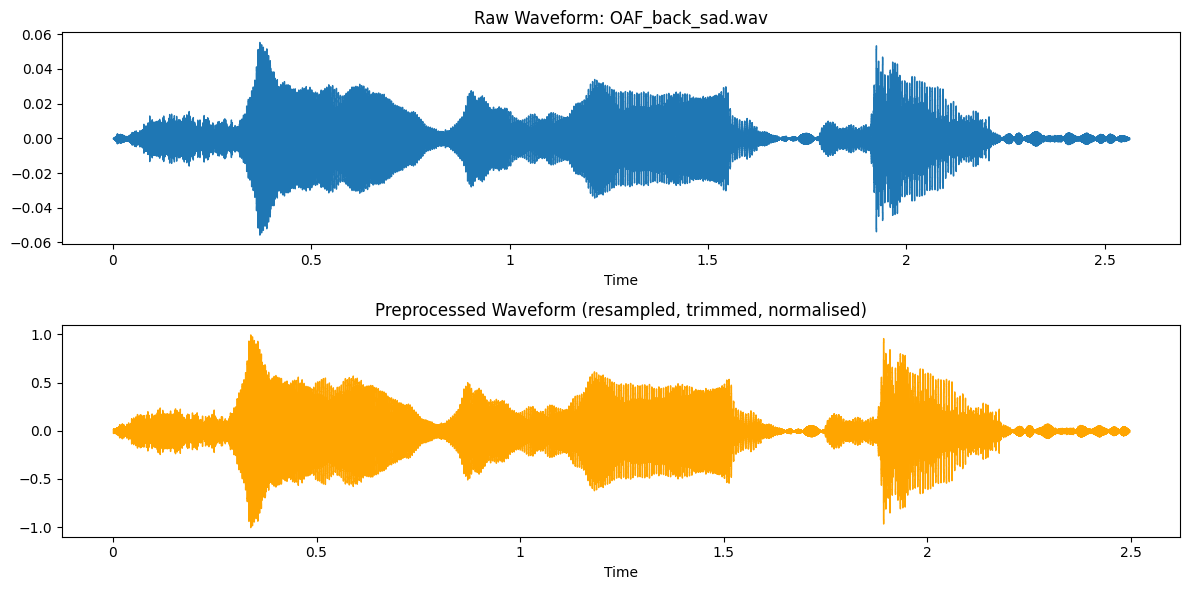

In [8]:
TARGET_SR = 16000          # target sampling rate (Hz)
TOP_DB = 25                # threshold (dB) below reference to consider as silence for trimming


def load_and_preprocess_audio(filepath, target_sr=TARGET_SR, top_db=TOP_DB):
    '''
    Load a WAV file, resample, trim silence, and normalise amplitude.
    Returns (waveform, sr) or (None, None) if the file cannot be processed.
    '''
    try:
        waveform, sr = librosa.load(filepath, sr=target_sr, mono=True)

        if waveform is None or len(waveform) == 0:
            return None, None

        # Trim leading/trailing silence
        waveform, _ = librosa.effects.trim(waveform, top_db=top_db)

        if len(waveform) == 0:
            return None, None

        # Peak amplitude normalisation
        max_val = np.max(np.abs(waveform))
        if max_val > 0:
            waveform = waveform / max_val

        return waveform, sr
    except Exception as e:
        print(f"[SKIPPED] Could not process '{filepath}': {e}")
        return None, None


# ---------------- Demonstration on a sample file ----------------
if not audio_df.empty:
    sample_path = audio_df.iloc[0]['filepath']
    raw_wave, raw_sr = librosa.load(sample_path, sr=None, mono=True)
    proc_wave, proc_sr = load_and_preprocess_audio(sample_path)

    if proc_wave is not None:
        fig, axes = plt.subplots(2, 1, figsize=(12, 6))
        librosa.display.waveshow(raw_wave, sr=raw_sr, ax=axes[0])
        axes[0].set_title(f"Raw Waveform: {os.path.basename(sample_path)}")

        librosa.display.waveshow(proc_wave, sr=proc_sr, ax=axes[1], color='orange')
        axes[1].set_title("Preprocessed Waveform (resampled, trimmed, normalised)")
        plt.tight_layout()
        plt.show()
else:
    print("No audio files available for demonstration. Check ROOT_DIR / AUDIO_DIR paths.")


## Audio Feature Extraction


In [9]:
N_MFCC = 40
N_MELS = 128
N_CHROMA = 12
N_CONTRAST_BANDS = 7  # librosa default -> 7 contrast values


def extract_audio_features(waveform, sr):
    '''
    Extract a fixed-length hand-crafted acoustic feature vector from a preprocessed waveform.
    Returns a 1D numpy array of shape (192,).
    '''
    features = []

    # MFCC (40)
    mfcc = librosa.feature.mfcc(y=waveform, sr=sr, n_mfcc=N_MFCC)
    features.append(np.mean(mfcc, axis=1))

    # Mel-Spectrogram (128), converted to dB scale for a more perceptually meaningful range
    mel = librosa.feature.melspectrogram(y=waveform, sr=sr, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    features.append(np.mean(mel_db, axis=1))

    # Chroma (12)
    chroma = librosa.feature.chroma_stft(y=waveform, sr=sr)
    features.append(np.mean(chroma, axis=1))

    # Zero Crossing Rate (1)
    zcr = librosa.feature.zero_crossing_rate(waveform)
    features.append(np.mean(zcr, axis=1))

    # Spectral Centroid (1)
    centroid = librosa.feature.spectral_centroid(y=waveform, sr=sr)
    features.append(np.mean(centroid, axis=1))

    # Spectral Bandwidth (1)
    bandwidth = librosa.feature.spectral_bandwidth(y=waveform, sr=sr)
    features.append(np.mean(bandwidth, axis=1))

    # Spectral Contrast (7)
    contrast = librosa.feature.spectral_contrast(y=waveform, sr=sr)
    features.append(np.mean(contrast, axis=1))

    # Spectral Roll-off (1)
    rolloff = librosa.feature.spectral_rolloff(y=waveform, sr=sr)
    features.append(np.mean(rolloff, axis=1))

    # RMS Energy (1)
    rms = librosa.feature.rms(y=waveform)
    features.append(np.mean(rms, axis=1))

    return np.concatenate(features).astype(np.float32)


def build_audio_feature_dataset(df, print_every=25):
    '''
    Iterate over every row of the audio dataframe, preprocess and extract features.
    Corrupted/unreadable files are skipped. Returns (X, y, skipped_files).
    '''
    feature_list = []
    label_list = []
    skipped = []

    total = len(df)
    for idx, row in df.iterrows():
        filepath = row['filepath']
        label = row['label']

        waveform, sr = load_and_preprocess_audio(filepath)
        if waveform is None:
            skipped.append(filepath)
            continue

        try:
            feats = extract_audio_features(waveform, sr)
            feature_list.append(feats)
            label_list.append(label)
        except Exception as e:
            print(f"[SKIPPED] Feature extraction failed for '{filepath}': {e}")
            skipped.append(filepath)
            continue

        if (idx + 1) % print_every == 0 or (idx + 1) == total:
            print(f"Processed {idx + 1}/{total} audio files...")

    X = np.array(feature_list, dtype=np.float32)
    y = np.array(label_list)
    print(f"\nFeature extraction complete. Extracted {X.shape[0]} feature vectors "
          f"of dimensionality {X.shape[1] if X.size else 0}.")
    print(f"Skipped {len(skipped)} corrupted/unreadable files.")
    return X, y, skipped


# ---------------- Run feature extraction across the full audio dataset ----------------
if not audio_df.empty:
    X_audio, y_audio_raw, skipped_files = build_audio_feature_dataset(audio_df)

    audio_label_encoder = LabelEncoder()
    audio_label_encoder.fit(AUDIO_CLASSES)  # ensures Normal=0, Depression=1 mapping is fixed
    y_audio = audio_label_encoder.transform(y_audio_raw)

    print("\nLabel mapping:", dict(zip(audio_label_encoder.classes_,
                                        audio_label_encoder.transform(audio_label_encoder.classes_))))
    print("Feature matrix shape:", X_audio.shape)
    print("Label vector shape  :", y_audio.shape)
else:
    print("No audio data available - skipping feature extraction.")
    X_audio, y_audio = np.array([]), np.array([])


Processed 25/400 audio files...
Processed 50/400 audio files...
Processed 75/400 audio files...
Processed 100/400 audio files...
Processed 125/400 audio files...
Processed 150/400 audio files...
Processed 175/400 audio files...
Processed 200/400 audio files...
Processed 225/400 audio files...
Processed 250/400 audio files...
Processed 275/400 audio files...
Processed 300/400 audio files...
Processed 325/400 audio files...
Processed 350/400 audio files...
Processed 375/400 audio files...
Processed 400/400 audio files...

Feature extraction complete. Extracted 400 feature vectors of dimensionality 192.
Skipped 0 corrupted/unreadable files.

Label mapping: {'Depression': 0, 'Normal': 1}
Feature matrix shape: (400, 192)
Label vector shape  : (400,)


## Audio Model Development — CNN + BiLSTM Hybrid


In [10]:
def prepare_audio_splits(X, y, test_size=0.2, val_size=0.1, seed=SEED):
    '''Stratified split into train / validation / test sets.'''
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(test_size + val_size), random_state=seed, stratify=y
    )
    relative_val = val_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - relative_val), random_state=seed, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def build_audio_cnn_bilstm(input_dim, n_classes):
    '''
    Functional-API CNN + BiLSTM hybrid model for audio classification.
    Input: (input_dim,) hand-crafted feature vector, reshaped to (input_dim, 1) for Conv1D.
    '''
    inputs = Input(shape=(input_dim, 1), name="audio_features_input")

    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dropout(0.4)(x)

    embedding = layers.Dense(64, activation='relu', name="audio_embedding")(x)
    x = layers.Dropout(0.3)(embedding)
    outputs = layers.Dense(n_classes, activation='softmax', name="audio_output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Audio_CNN_BiLSTM")
    return model


if X_audio.size:
    # Standardise features (zero mean, unit variance) - fit on train only
    (X_train_a, X_val_a, X_test_a,
     y_train_a, y_val_a, y_test_a) = prepare_audio_splits(X_audio, y_audio)

    audio_scaler = StandardScaler()
    X_train_a = audio_scaler.fit_transform(X_train_a)
    X_val_a = audio_scaler.transform(X_val_a)
    X_test_a = audio_scaler.transform(X_test_a)

    N_AUDIO_CLASSES = len(AUDIO_CLASSES)
    y_train_a_cat = to_categorical(y_train_a, num_classes=N_AUDIO_CLASSES)
    y_val_a_cat = to_categorical(y_val_a, num_classes=N_AUDIO_CLASSES)
    y_test_a_cat = to_categorical(y_test_a, num_classes=N_AUDIO_CLASSES)

    # Reshape for Conv1D: (samples, features, 1)
    X_train_a_r = X_train_a[..., np.newaxis]
    X_val_a_r = X_val_a[..., np.newaxis]
    X_test_a_r = X_test_a[..., np.newaxis]

    audio_model = build_audio_cnn_bilstm(input_dim=X_train_a.shape[1], n_classes=N_AUDIO_CLASSES)
    audio_model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )
    audio_model.summary()

    # Class weights to handle Normal/Depression imbalance
    class_weights_a = compute_class_weight('balanced', classes=np.unique(y_train_a), y=y_train_a)
    class_weight_dict_a = dict(enumerate(class_weights_a))
    print("\nAudio class weights:", class_weight_dict_a)
else:
    print("No audio features available - audio model construction skipped.")


Model: "Audio_CNN_BiLSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 audio_features_input (Input  [(None, 192, 1)]         0         
 Layer)                                                          
                                                                 
 conv1d (Conv1D)             (None, 192, 64)           256       
                                                                 
 batch_normalization (BatchN  (None, 192, 64)          256       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 96, 64)           0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 96, 64)            0         
                                                  

In [12]:
if X_audio.size:
    audio_callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint('best_audio_model.h5', monitor='val_loss', save_best_only=True, verbose=0)
    ]

    audio_history = audio_model.fit(
        X_train_a_r, y_train_a_cat,
        validation_data=(X_val_a_r, y_val_a_cat),
        epochs=10,
        batch_size=32,
        class_weight=class_weight_dict_a,
        callbacks=audio_callbacks,
        verbose=1
    )
else:
    audio_history = None
    print("Skipping audio model training - no data available.")


Epoch 1/10
9/9 [==============================] - 0s 46ms/step - loss: 0.2306 - accuracy: 0.9211 - precision: 0.9211 - recall: 0.9211 - auc: 0.9655 - val_loss: 0.5911 - val_accuracy: 0.7000 - val_precision: 0.7000 - val_recall: 0.7000 - val_auc: 0.8406 - lr: 0.0010
Epoch 2/10
9/9 [==============================] - 0s 22ms/step - loss: 0.2105 - accuracy: 0.9355 - precision: 0.9355 - recall: 0.9355 - auc: 0.9714 - val_loss: 0.5989 - val_accuracy: 0.7000 - val_precision: 0.7000 - val_recall: 0.7000 - val_auc: 0.8294 - lr: 0.0010
Epoch 3/10
9/9 [==============================] - 0s 19ms/step - loss: 0.2041 - accuracy: 0.9283 - precision: 0.9283 - recall: 0.9283 - auc: 0.9717 - val_loss: 0.6006 - val_accuracy: 0.6750 - val_precision: 0.6750 - val_recall: 0.6750 - val_auc: 0.8256 - lr: 0.0010
Epoch 4/10
9/9 [==============================] - 0s 19ms/step - loss: 0.1468 - accuracy: 0.9498 - precision: 0.9498 - recall: 0.9498 - auc: 0.9895 - val_loss: 0.5951 - val_accuracy: 0.7000 - val_precis

### Audio Model Training Curves

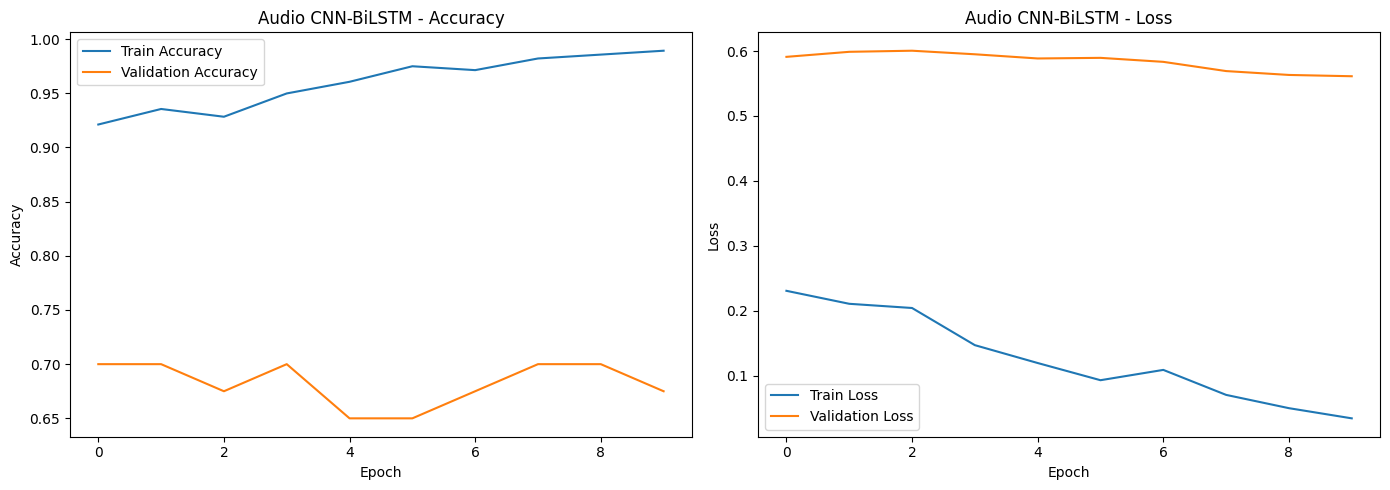

In [13]:
def plot_training_curves(history, title_prefix):
    '''Plot Accuracy and Loss curves for train/validation sets.'''
    if history is None:
        print(f"No training history available for {title_prefix}.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title(f'{title_prefix} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title(f'{title_prefix} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_training_curves(audio_history, "Audio CNN-BiLSTM")


## 10. Facial Data Preprocessing


Found 24406 images belonging to 7 classes.
Found 4303 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


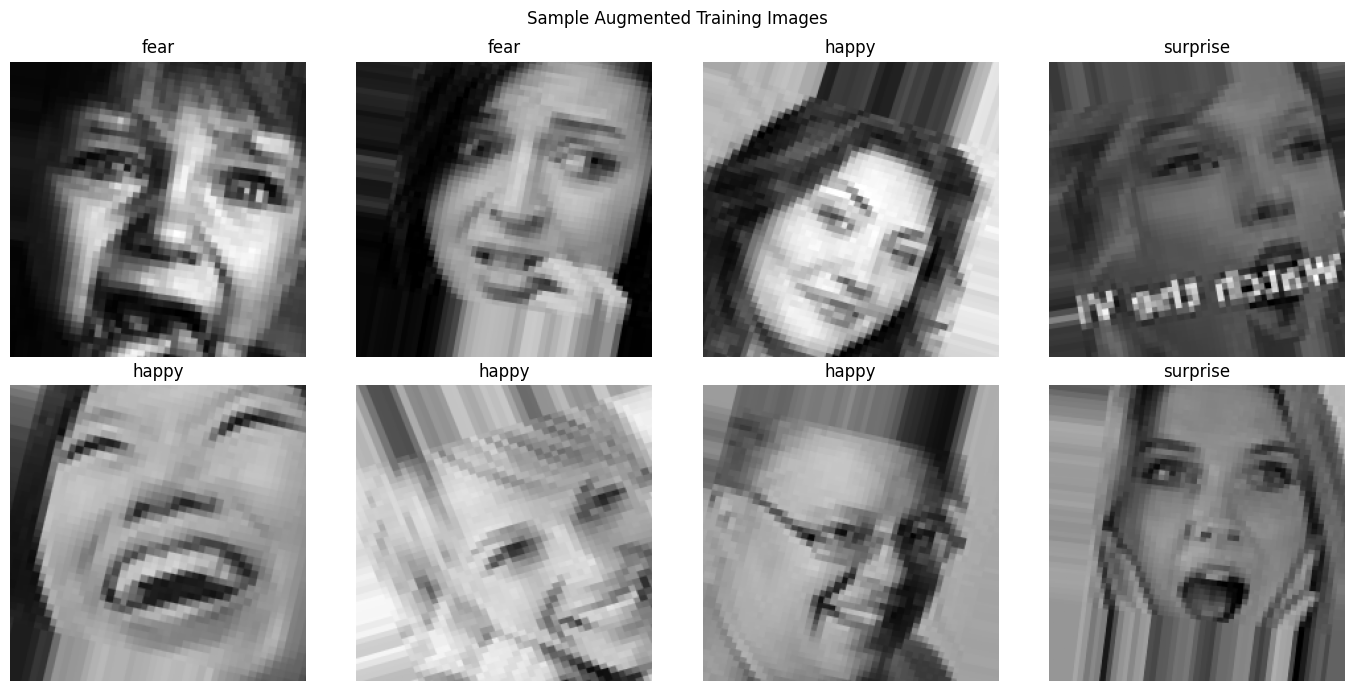

In [14]:
def build_facial_generators(train_dir, test_dir, img_size=IMG_SIZE, batch_size=BATCH_SIZE, val_split=0.15):
    '''
    Build train / validation / test ImageDataGenerator flows directly from directory structure.
    Validation is carved out of the training directory (no augmentation applied to it).
    '''
    train_datagen = ImageDataGenerator(
        rescale=1. / 255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True,
        width_shift_range=0.15,
        height_shift_range=0.15,
        brightness_range=[0.8, 1.2],
        validation_split=val_split
    )

    eval_datagen = ImageDataGenerator(rescale=1. / 255)          # for validation split (no augmentation)
    test_datagen = ImageDataGenerator(rescale=1. / 255)          # for held-out test set

    train_gen = train_datagen.flow_from_directory(
        train_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', subset='training', shuffle=True, seed=SEED
    )

    val_gen = eval_datagen.flow_from_directory(
        train_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', subset=None, shuffle=False
    ) if val_split == 0 else train_datagen.flow_from_directory(
        train_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', subset='validation', shuffle=False, seed=SEED
    )

    test_gen = test_datagen.flow_from_directory(
        test_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', shuffle=False
    )

    return train_gen, val_gen, test_gen


if os.path.isdir(FACIAL_TRAIN_DIR):
    facial_train_gen, facial_val_gen, facial_test_gen = build_facial_generators(
        FACIAL_TRAIN_DIR, FACIAL_TEST_DIR
    )
    print("\nClass indices:", facial_train_gen.class_indices)

    # ---- Visualise a batch of augmented training images ----
    images, labels = next(facial_train_gen)
    idx_to_class = {v: k for k, v in facial_train_gen.class_indices.items()}

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i])
            ax.set_title(idx_to_class[np.argmax(labels[i])])
            ax.axis('off')
    plt.suptitle("Sample Augmented Training Images")
    plt.tight_layout()
    plt.show()
else:
    print(f"[WARNING] Facial dataset not found at {FACIAL_TRAIN_DIR} - generators not created.")
    facial_train_gen = facial_val_gen = facial_test_gen = None


## 11. Facial Emotion Recognition using Custom CNN

In [15]:
def build_custom_cnn(input_shape, n_classes):
    '''Custom CNN built with the Keras Functional API.'''
    inputs = Input(shape=input_shape, name="facial_image_input")

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    embedding = layers.Dense(128, activation='relu', name="custom_cnn_embedding")(x)
    x = layers.Dropout(0.4)(embedding)
    outputs = layers.Dense(n_classes, activation='softmax', name="custom_cnn_output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Custom_CNN")
    return model


if facial_train_gen is not None:
    N_FACIAL_CLASSES = facial_train_gen.num_classes

    custom_cnn = build_custom_cnn(input_shape=(*IMG_SIZE, 3), n_classes=N_FACIAL_CLASSES)
    custom_cnn.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )
    custom_cnn.summary()
else:
    custom_cnn = None
    print("Facial generators unavailable - Custom CNN construction skipped.")


Model: "Custom_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 facial_image_input (InputLa  [(None, 224, 224, 3)]    0         
 yer)                                                            
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_2 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 dropout_4 (Dropout)         (None, 112, 112, 32)      0         
                                                        

In [19]:
if facial_train_gen is not None:
    custom_cnn_callbacks = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
        ModelCheckpoint('best_custom_cnn.h5', monitor='val_loss', save_best_only=True, verbose=0)
    ]

    custom_cnn_history = custom_cnn.fit(
        facial_train_gen,
        validation_data=facial_val_gen,
        epochs=10,
        callbacks=custom_cnn_callbacks,
        verbose=1
    )
else:
    custom_cnn_history = None
    print("Skipping Custom CNN training - no data available.")


Epoch 1/10
763/763 [==============================] - 214s 280ms/step - loss: 1.6855 - accuracy: 0.3230 - precision: 0.6010 - recall: 0.0335 - auc: 0.7261 - val_loss: 6.7428 - val_accuracy: 0.1418 - val_precision: 0.1390 - val_recall: 0.1246 - val_auc: 0.5127 - lr: 0.0010
Epoch 2/10
763/763 [==============================] - 211s 276ms/step - loss: 1.6601 - accuracy: 0.3420 - precision: 0.6178 - recall: 0.0515 - auc: 0.7381 - val_loss: 1.9205 - val_accuracy: 0.2803 - val_precision: 0.3246 - val_recall: 0.2045 - val_auc: 0.7015 - lr: 0.0010
Epoch 3/10
763/763 [==============================] - 212s 277ms/step - loss: 1.6357 - accuracy: 0.3538 - precision: 0.6323 - recall: 0.0656 - auc: 0.7488 - val_loss: 1.7529 - val_accuracy: 0.2705 - val_precision: 0.7778 - val_recall: 0.0016 - val_auc: 0.6887 - lr: 0.0010
Epoch 4/10
763/763 [==============================] - 220s 288ms/step - loss: 1.6078 - accuracy: 0.3675 - precision: 0.6458 - recall: 0.0853 - auc: 0.7596 - val_loss: 2.7334 - val_a

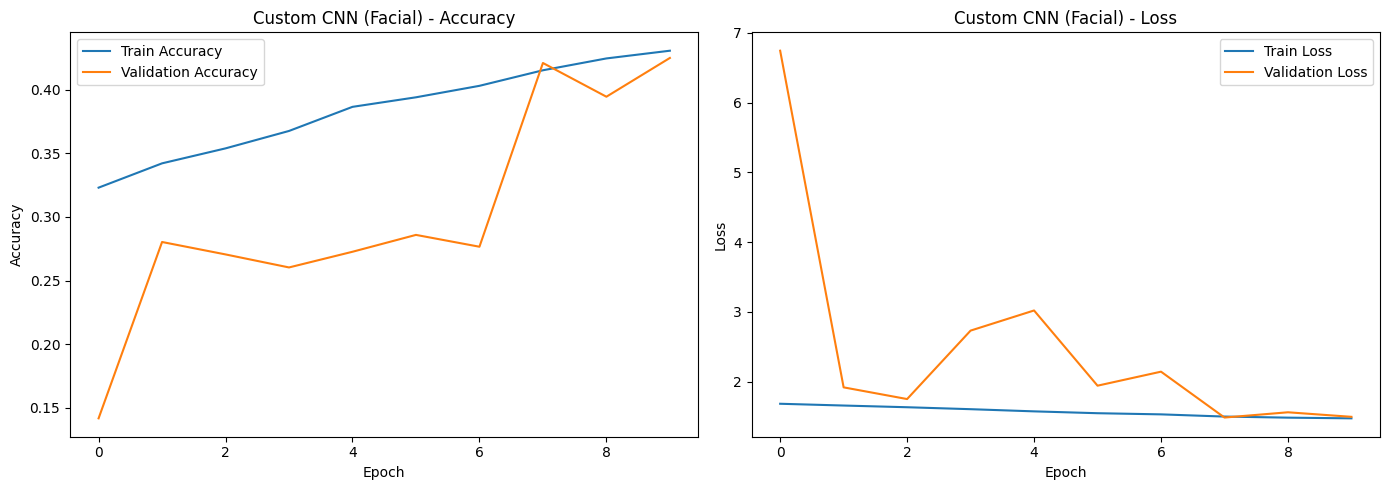

In [20]:
plot_training_curves(custom_cnn_history, "Custom CNN (Facial)")


## Facial Emotion Recognition using EfficientNetB0 (Transfer Learning)


In [21]:
def build_efficientnet_model(input_shape, n_classes, unfreeze_last_n=20):
    '''
    EfficientNetB0 transfer-learning model.
    Returns (model, base_model) so the caller can freeze/unfreeze layers for fine-tuning.
    '''
    base_model = EfficientNetB0(
        include_top=False, weights='imagenet', input_shape=input_shape, pooling=None
    )
    base_model.trainable = False  # Phase 1: freeze entirely

    inputs = Input(shape=input_shape, name="facial_image_input_effnet")
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    embedding = layers.Dense(128, activation='relu', name="effnet_embedding")(x)
    x = layers.Dropout(0.4)(embedding)
    outputs = layers.Dense(n_classes, activation='softmax', name="effnet_output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="EfficientNetB0_Transfer")
    return model, base_model


if facial_train_gen is not None:
    effnet_model, effnet_base = build_efficientnet_model(input_shape=(*IMG_SIZE, 3), n_classes=N_FACIAL_CLASSES)
    effnet_model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )
    effnet_model.summary()
else:
    effnet_model = effnet_base = None
    print("Facial generators unavailable - EfficientNetB0 construction skipped.")


Model: "EfficientNetB0_Transfer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 facial_image_input_effnet (  [(None, 224, 224, 3)]    0         
 InputLayer)                                                     
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 effnet_embedding (Dense)    (None, 128)               163968    
                                                                 
 dropout_7 (Dropout)         (None, 128)               0         
                                                                 
 effnet_output (Dense)       (None, 7)     

### Phase 1 — Train Classification Head (Frozen Base)


In [22]:
if effnet_model is not None:
    effnet_phase1_callbacks = [
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ]

    effnet_history_phase1 = effnet_model.fit(
        facial_train_gen,
        validation_data=facial_val_gen,
        epochs=10,
        callbacks=effnet_phase1_callbacks,
        verbose=1
    )
else:
    effnet_history_phase1 = None
    print("Skipping EfficientNetB0 Phase 1 training - no data available.")


Epoch 1/10
763/763 [==============================] - 220s 283ms/step - loss: 1.8311 - accuracy: 0.2407 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.6344 - val_loss: 1.8108 - val_accuracy: 0.2515 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.6425 - lr: 0.0010
Epoch 2/10
763/763 [==============================] - 217s 284ms/step - loss: 1.8189 - accuracy: 0.2513 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.6411 - val_loss: 1.8102 - val_accuracy: 0.2515 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.6436 - lr: 0.0010
Epoch 3/10
763/763 [==============================] - 213s 279ms/step - loss: 1.8164 - accuracy: 0.2513 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.6431 - val_loss: 1.8106 - val_accuracy: 0.2515 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.6433 - lr: 0.0010
Epoch 4/10
763/763 [==============================] - 215s 281ms/step - loss: 1.8167 - accuracy: 0.2513 - precision: 0.0000e+00 - rec

### Phase 2 — Fine-Tuning (Unfreeze Last Layers)

In [24]:
if effnet_model is not None:
    # Unfreeze the last 20 layers of the base model for fine-tuning
    effnet_base.trainable = True
    UNFREEZE_LAST_N = 20
    for layer in effnet_base.layers[:-UNFREEZE_LAST_N]:
        layer.trainable = False

    effnet_model.compile(
        optimizer=Adam(learning_rate=1e-5),   # much lower LR for fine-tuning
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )

    effnet_phase2_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint('best_efficientnet_model.weights.h5', monitor='val_loss',
                     save_best_only=True, save_weights_only=True, verbose=0)
    ]

    effnet_history_phase2 = effnet_model.fit(
        facial_train_gen,
        validation_data=facial_val_gen,
        epochs=10,
        callbacks=effnet_phase2_callbacks,
        verbose=1
    )
else:
    effnet_history_phase2 = None
    print("Skipping EfficientNetB0 Phase 2 fine-tuning - no data available.")


Epoch 1/10
763/763 [==============================] - 217s 279ms/step - loss: 1.8110 - accuracy: 0.2513 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.6433 - val_loss: 1.8100 - val_accuracy: 0.2515 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.6439 - lr: 1.0000e-05
Epoch 2/10
763/763 [==============================] - 208s 273ms/step - loss: 1.8110 - accuracy: 0.2513 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.6437 - val_loss: 1.8095 - val_accuracy: 0.2515 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.6439 - lr: 1.0000e-05
Epoch 3/10
763/763 [==============================] - 216s 283ms/step - loss: 1.8109 - accuracy: 0.2513 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.6435 - val_loss: 1.8098 - val_accuracy: 0.2515 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.6439 - lr: 1.0000e-05
Epoch 4/10
763/763 [==============================] - 218s 286ms/step - loss: 1.8103 - accuracy: 0.2513 - precision: 0.00

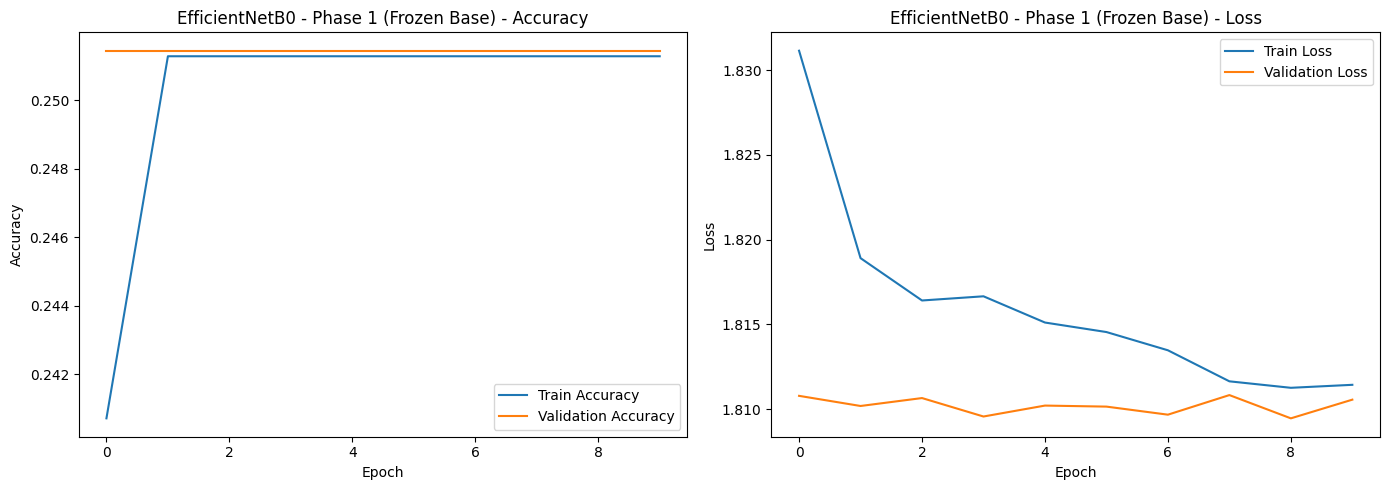

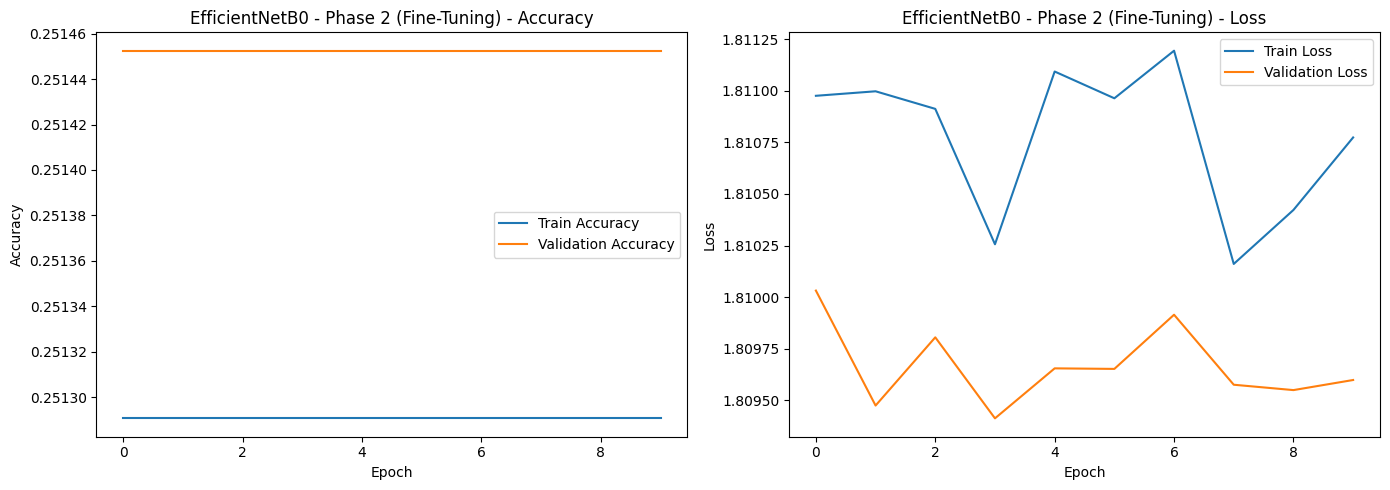

In [25]:
plot_training_curves(effnet_history_phase1, "EfficientNetB0 - Phase 1 (Frozen Base)")
plot_training_curves(effnet_history_phase2, "EfficientNetB0 - Phase 2 (Fine-Tuning)")


## Multimodal Data Fusion


In [26]:
AFFECT_MAP_FACIAL = {
    "happy": 0, "neutral": 0, "surprise": 0,          # Non-Negative Affect
    "angry": 1, "disgust": 1, "fear": 1, "sad": 1,     # Negative Affect
}
AFFECT_MAP_AUDIO = {
    "Normal": 0,        # Non-Negative Affect
    "Depression": 1,    # Negative Affect
}
FUSION_CLASSES = ["Non-Negative Affect", "Negative Affect"]


def extract_embedding_model(trained_model, embedding_layer_name):
    '''Build a sub-model that outputs the activations of a named embedding layer.'''
    return Model(inputs=trained_model.input,
                 outputs=trained_model.get_layer(embedding_layer_name).output)


def get_facial_embeddings_and_labels(embedding_model, generator):
    '''
    Run the embedding model over every batch of a (non-shuffled) generator,
    returning embeddings plus the original emotion-class label per sample.
    '''
    generator.reset()
    idx_to_class = {v: k for k, v in generator.class_indices.items()}
    embeddings, emotion_labels = [], []

    steps = int(np.ceil(generator.samples / generator.batch_size))
    for step in range(steps):
        images, labels = next(generator)
        emb = embedding_model.predict(images, verbose=0)
        embeddings.append(emb)
        emotion_labels.extend([idx_to_class[i] for i in np.argmax(labels, axis=1)])

    return np.concatenate(embeddings, axis=0), np.array(emotion_labels)


def pair_modalities_by_affect(facial_emb, facial_emotion_labels, audio_emb, audio_class_labels, seed=SEED):
    '''
    Pair facial and audio embeddings that share the same affective-polarity label
    (random sampling with replacement within each polarity group).
    '''
    rng = np.random.RandomState(seed)

    facial_polarity = np.array([AFFECT_MAP_FACIAL[l] for l in facial_emotion_labels])
    audio_polarity = np.array([AFFECT_MAP_AUDIO[l] for l in audio_class_labels])

    fused_X, fused_y = [], []
    for polarity in [0, 1]:
        f_idx = np.where(facial_polarity == polarity)[0]
        a_idx = np.where(audio_polarity == polarity)[0]
        if len(f_idx) == 0 or len(a_idx) == 0:
            continue

        n_pairs = max(len(f_idx), len(a_idx))
        sampled_f = rng.choice(f_idx, size=n_pairs, replace=True)
        sampled_a = rng.choice(a_idx, size=n_pairs, replace=True)

        for fi, ai in zip(sampled_f, sampled_a):
            fused_X.append(np.concatenate([facial_emb[fi], audio_emb[ai]]))
            fused_y.append(polarity)

    return np.array(fused_X, dtype=np.float32), np.array(fused_y)


def build_fusion_model(input_dim, n_classes):
    '''Dense fusion head operating on concatenated facial+audio embeddings.'''
    inputs = Input(shape=(input_dim,), name="fused_embedding_input")
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax', name="fusion_output")(x)
    return Model(inputs=inputs, outputs=outputs, name="Multimodal_Fusion_Model")


fusion_ready = (facial_train_gen is not None) and (X_audio.size > 0) and (custom_cnn_history is not None)

if fusion_ready:
    # ---- Select best facial model by validation accuracy ----
    best_custom_cnn_val_acc = max(custom_cnn_history.history['val_accuracy']) if custom_cnn_history else 0
    best_effnet_val_acc = max(effnet_history_phase2.history['val_accuracy']) if effnet_history_phase2 else 0

    if best_effnet_val_acc >= best_custom_cnn_val_acc:
        print(f"Selected facial model for fusion: EfficientNetB0 (val_acc={best_effnet_val_acc:.4f})")
        facial_embed_model = extract_embedding_model(effnet_model, "effnet_embedding")
    else:
        print(f"Selected facial model for fusion: Custom CNN (val_acc={best_custom_cnn_val_acc:.4f})")
        facial_embed_model = extract_embedding_model(custom_cnn, "custom_cnn_embedding")

    audio_embed_model = extract_embedding_model(audio_model, "audio_embedding")

    # ---- Extract embeddings ----
    facial_emb_train, facial_emotion_train = get_facial_embeddings_and_labels(facial_embed_model, facial_train_gen)
    facial_emb_val, facial_emotion_val = get_facial_embeddings_and_labels(facial_embed_model, facial_val_gen)

    audio_emb_train = audio_embed_model.predict(X_train_a_r, verbose=0)
    audio_emb_val = audio_embed_model.predict(X_val_a_r, verbose=0)

    audio_class_train = audio_label_encoder.inverse_transform(y_train_a)
    audio_class_val = audio_label_encoder.inverse_transform(y_val_a)

    print(f"Facial train embeddings: {facial_emb_train.shape}, Audio train embeddings: {audio_emb_train.shape}")

    # ---- Pair modalities by shared affective polarity ----
    X_fusion_train, y_fusion_train = pair_modalities_by_affect(
        facial_emb_train, facial_emotion_train, audio_emb_train, audio_class_train
    )
    X_fusion_val, y_fusion_val = pair_modalities_by_affect(
        facial_emb_val, facial_emotion_val, audio_emb_val, audio_class_val
    )

    print(f"Fusion train set: {X_fusion_train.shape}, Fusion val set: {X_fusion_val.shape}")

    N_FUSION_CLASSES = len(FUSION_CLASSES)
    y_fusion_train_cat = to_categorical(y_fusion_train, num_classes=N_FUSION_CLASSES)
    y_fusion_val_cat = to_categorical(y_fusion_val, num_classes=N_FUSION_CLASSES)

    fusion_model = build_fusion_model(input_dim=X_fusion_train.shape[1], n_classes=N_FUSION_CLASSES)
    fusion_model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )
    fusion_model.summary()
else:
    fusion_model = None
    print("Fusion prerequisites not met (facial and/or audio models unavailable) - fusion skipped.")


Selected facial model for fusion: Custom CNN (val_acc=0.4248)
Facial train embeddings: (24406, 128), Audio train embeddings: (279, 64)
Fusion train set: (24406, 192), Fusion val set: (4303, 192)
Model: "Multimodal_Fusion_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fused_embedding_input (Inpu  [(None, 192)]            0         
 tLayer)                                                         
                                                                 
 dense (Dense)               (None, 128)               24704     
                                                                 
 batch_normalization_5 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 dropout_8 (Dropout)         (None, 128)               0         
                                              

Epoch 1/10
763/763 [==============================] - 6s 7ms/step - loss: 0.1686 - accuracy: 0.9343 - precision: 0.9343 - recall: 0.9343 - auc: 0.9827 - val_loss: 0.0832 - val_accuracy: 0.9677 - val_precision: 0.9677 - val_recall: 0.9677 - val_auc: 0.9967 - lr: 0.0010
Epoch 2/10
763/763 [==============================] - 5s 6ms/step - loss: 0.0845 - accuracy: 0.9685 - precision: 0.9685 - recall: 0.9685 - auc: 0.9952 - val_loss: 0.0641 - val_accuracy: 0.9733 - val_precision: 0.9733 - val_recall: 0.9733 - val_auc: 0.9977 - lr: 0.0010
Epoch 3/10
763/763 [==============================] - 5s 6ms/step - loss: 0.0656 - accuracy: 0.9753 - precision: 0.9753 - recall: 0.9753 - auc: 0.9971 - val_loss: 0.0509 - val_accuracy: 0.9798 - val_precision: 0.9798 - val_recall: 0.9798 - val_auc: 0.9987 - lr: 0.0010
Epoch 4/10
763/763 [==============================] - 5s 7ms/step - loss: 0.0612 - accuracy: 0.9771 - precision: 0.9771 - recall: 0.9771 - auc: 0.9974 - val_loss: 0.0738 - val_accuracy: 0.9689 

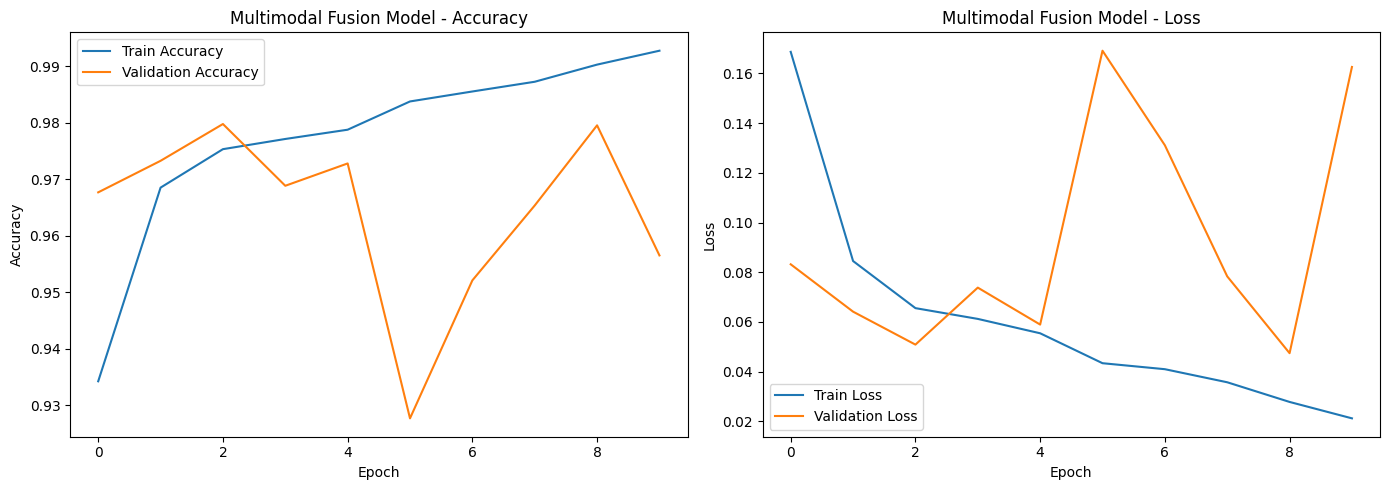

In [27]:
if fusion_ready:
    fusion_callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ]

    fusion_history = fusion_model.fit(
        X_fusion_train, y_fusion_train_cat,
        validation_data=(X_fusion_val, y_fusion_val_cat),
        epochs=10,
        batch_size=32,
        callbacks=fusion_callbacks,
        verbose=1
    )
    plot_training_curves(fusion_history, "Multimodal Fusion Model")
else:
    fusion_history = None
    print("Skipping fusion model training.")


## Model Evaluation


In [29]:
def evaluate_classifier(y_true, y_pred_probs, class_names, model_name):
    '''
    Compute and display Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix and Classification Report
    for a multi-class (or binary) classifier given true integer labels and predicted probabilities.
    '''
    y_pred = np.argmax(y_pred_probs, axis=1)
    n_classes = len(class_names)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    try:
        if n_classes == 2:
            roc_auc = roc_auc_score(y_true, y_pred_probs[:, 1])
        else:
            y_true_bin = to_categorical(y_true, num_classes=n_classes)
            roc_auc = roc_auc_score(y_true_bin, y_pred_probs, average='macro', multi_class='ovr')
    except Exception as e:
        print(f"ROC-AUC could not be computed for {model_name}: {e}")
        roc_auc = np.nan

    print(f"\n{'=' * 60}\n{model_name} - Test Set Evaluation\n{'=' * 60}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # ROC Curve (one-vs-rest for each class)
    plt.figure(figsize=(7, 6))
    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:, 1])
        plt.plot(fpr, tpr, label=f"{class_names[1]} (AUC = {auc(fpr, tpr):.3f})")
    else:
        y_true_bin = to_categorical(y_true, num_classes=n_classes)
        for i, cname in enumerate(class_names):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
            plt.plot(fpr, tpr, label=f"{cname} (AUC = {auc(fpr, tpr):.3f})")

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

    return {"model": model_name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1_score": f1, "roc_auc": roc_auc}


results_summary = []


### Audio CNN-BiLSTM — Test Evaluation



Audio CNN-BiLSTM - Test Set Evaluation
Accuracy  : 0.6790
Precision : 0.8060
Recall    : 0.6750
F1-score  : 0.6389
ROC-AUC   : 0.9732

Classification Report:
               precision    recall  f1-score   support

      Normal       0.61      1.00      0.76        41
  Depression       1.00      0.35      0.52        40

    accuracy                           0.68        81
   macro avg       0.81      0.68      0.64        81
weighted avg       0.80      0.68      0.64        81



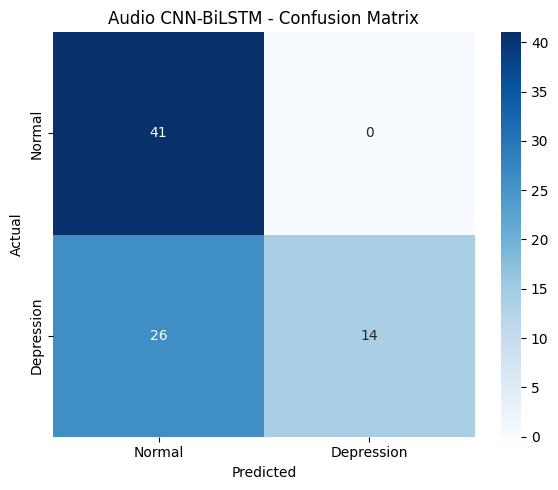

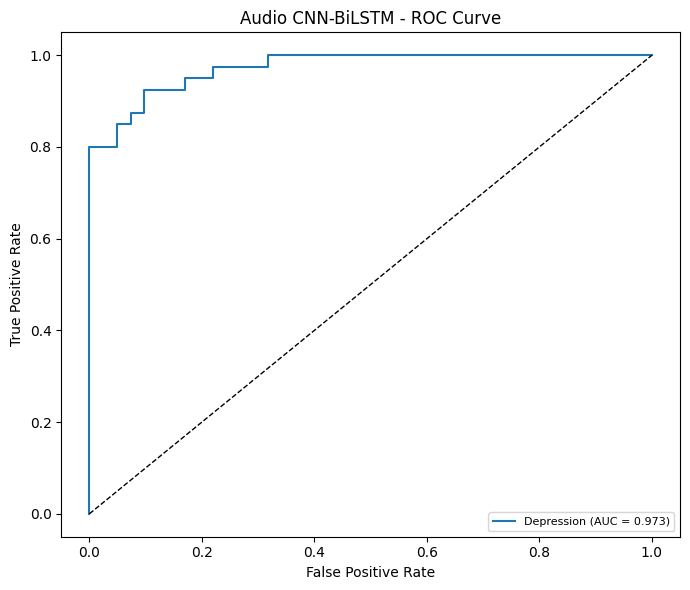

In [30]:
if X_audio.size:
    t0 = time.time()
    audio_test_probs = audio_model.predict(X_test_a_r, verbose=0)
    audio_inference_time = time.time() - t0

    audio_result = evaluate_classifier(y_test_a, audio_test_probs, AUDIO_CLASSES, "Audio CNN-BiLSTM")
    audio_result["inference_time_sec"] = audio_inference_time
    audio_result["n_params"] = audio_model.count_params()
    results_summary.append(audio_result)


### Custom CNN — Test Evaluation



Custom CNN - Test Set Evaluation
Accuracy  : 0.4069
Precision : 0.3432
Recall    : 0.3160
F1-score  : 0.2966
ROC-AUC   : 0.7455

Classification Report:
               precision    recall  f1-score   support

       angry       0.29      0.13      0.18       958
     disgust       0.00      0.00      0.00       111
        fear       0.18      0.01      0.02      1024
       happy       0.52      0.70      0.60      1774
     neutral       0.33      0.43      0.37      1233
         sad       0.30      0.55      0.39      1247
    surprise       0.77      0.39      0.51       831

    accuracy                           0.41      7178
   macro avg       0.34      0.32      0.30      7178
weighted avg       0.39      0.41      0.37      7178



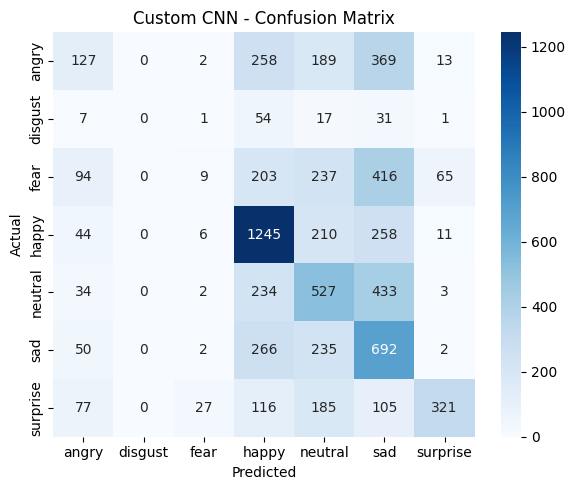

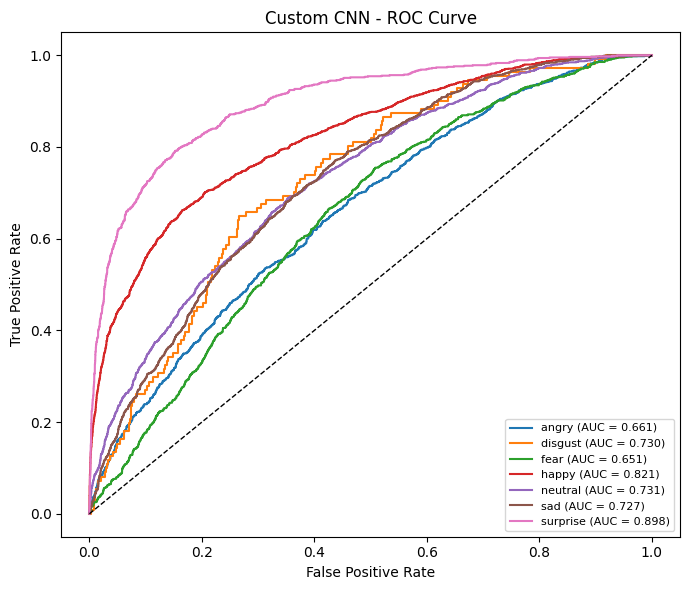

In [31]:
if facial_train_gen is not None and custom_cnn_history is not None:
    facial_test_gen.reset()
    t0 = time.time()
    custom_cnn_test_probs = custom_cnn.predict(facial_test_gen, verbose=0)
    custom_cnn_inference_time = time.time() - t0

    y_true_facial_test = facial_test_gen.classes
    facial_class_names = list(facial_test_gen.class_indices.keys())

    custom_cnn_result = evaluate_classifier(y_true_facial_test, custom_cnn_test_probs,
                                             facial_class_names, "Custom CNN")
    custom_cnn_result["inference_time_sec"] = custom_cnn_inference_time
    custom_cnn_result["n_params"] = custom_cnn.count_params()
    results_summary.append(custom_cnn_result)


### EfficientNetB0 — Test Evaluation



EfficientNetB0 - Test Set Evaluation
Accuracy  : 0.2471
Precision : 0.0353
Recall    : 0.1429
F1-score  : 0.0566
ROC-AUC   : 0.5296

Classification Report:
               precision    recall  f1-score   support

       angry       0.00      0.00      0.00       958
     disgust       0.00      0.00      0.00       111
        fear       0.00      0.00      0.00      1024
       happy       0.25      1.00      0.40      1774
     neutral       0.00      0.00      0.00      1233
         sad       0.00      0.00      0.00      1247
    surprise       0.00      0.00      0.00       831

    accuracy                           0.25      7178
   macro avg       0.04      0.14      0.06      7178
weighted avg       0.06      0.25      0.10      7178



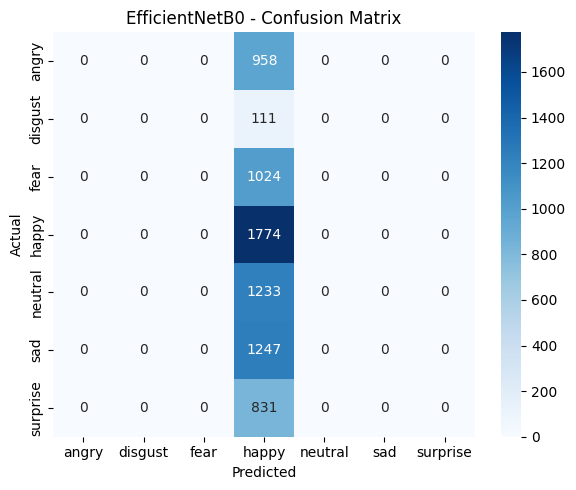

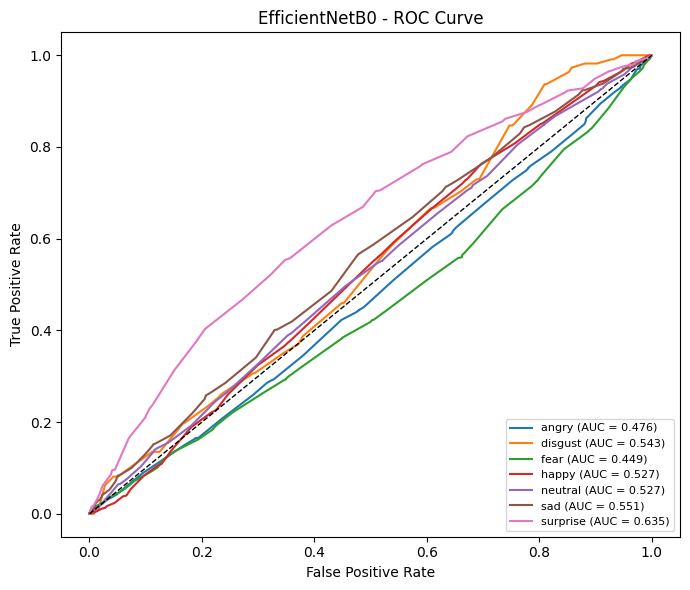

In [32]:
if facial_train_gen is not None and effnet_model is not None:
    facial_test_gen.reset()
    t0 = time.time()
    effnet_test_probs = effnet_model.predict(facial_test_gen, verbose=0)
    effnet_inference_time = time.time() - t0

    effnet_result = evaluate_classifier(y_true_facial_test, effnet_test_probs,
                                         facial_class_names, "EfficientNetB0")
    effnet_result["inference_time_sec"] = effnet_inference_time
    effnet_result["n_params"] = effnet_model.count_params()
    results_summary.append(effnet_result)


### Multimodal Fusion Model — Test Evaluation



Multimodal Fusion - Test Set Evaluation
Accuracy  : 0.9682
Precision : 0.9676
Recall    : 0.9692
F1-score  : 0.9681
ROC-AUC   : 0.9977

Classification Report:
                      precision    recall  f1-score   support

Non-Negative Affect       0.98      0.96      0.97      3838
    Negative Affect       0.95      0.98      0.97      3340

           accuracy                           0.97      7178
          macro avg       0.97      0.97      0.97      7178
       weighted avg       0.97      0.97      0.97      7178



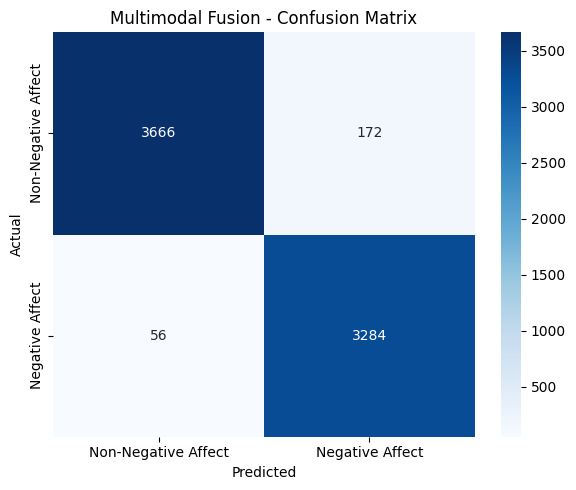

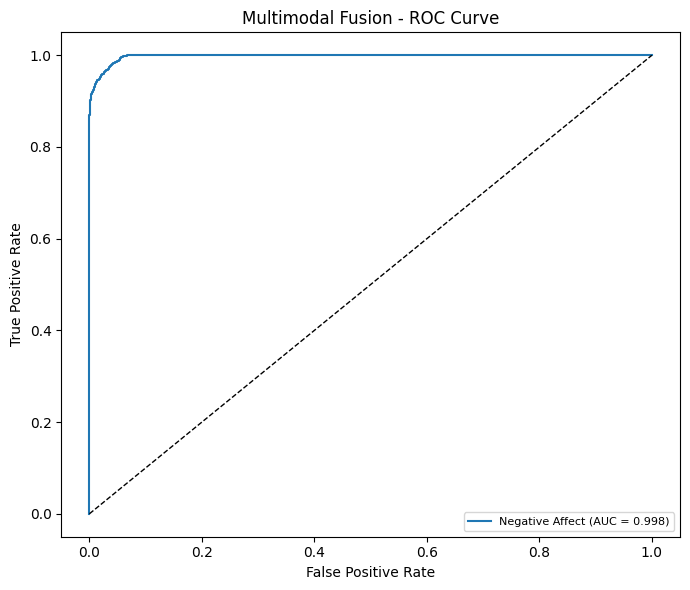

In [33]:
if fusion_ready:
    facial_emb_test, facial_emotion_test = get_facial_embeddings_and_labels(facial_embed_model, facial_test_gen)
    audio_emb_test = audio_embed_model.predict(X_test_a_r, verbose=0)
    audio_class_test = audio_label_encoder.inverse_transform(y_test_a)

    X_fusion_test, y_fusion_test = pair_modalities_by_affect(
        facial_emb_test, facial_emotion_test, audio_emb_test, audio_class_test
    )

    t0 = time.time()
    fusion_test_probs = fusion_model.predict(X_fusion_test, verbose=0)
    fusion_inference_time = time.time() - t0

    fusion_result = evaluate_classifier(y_fusion_test, fusion_test_probs, FUSION_CLASSES, "Multimodal Fusion")
    fusion_result["inference_time_sec"] = fusion_inference_time
    fusion_result["n_params"] = fusion_model.count_params()
    results_summary.append(fusion_result)


## Comparative Analysis

Model Comparison Table:

            model  accuracy  precision   recall  f1_score  roc_auc  inference_time_sec  n_params
Multimodal Fusion  0.968236   0.967593 0.969209  0.968146 0.997681            0.396340     33858
 Audio CNN-BiLSTM  0.679012   0.805970 0.675000  0.638889 0.973171            0.830165    132930
       Custom CNN  0.406938   0.343189 0.315970  0.296572 0.745475           44.562577    111559
   EfficientNetB0  0.247144   0.035306 0.142857  0.056619 0.529645           17.824420   4214442


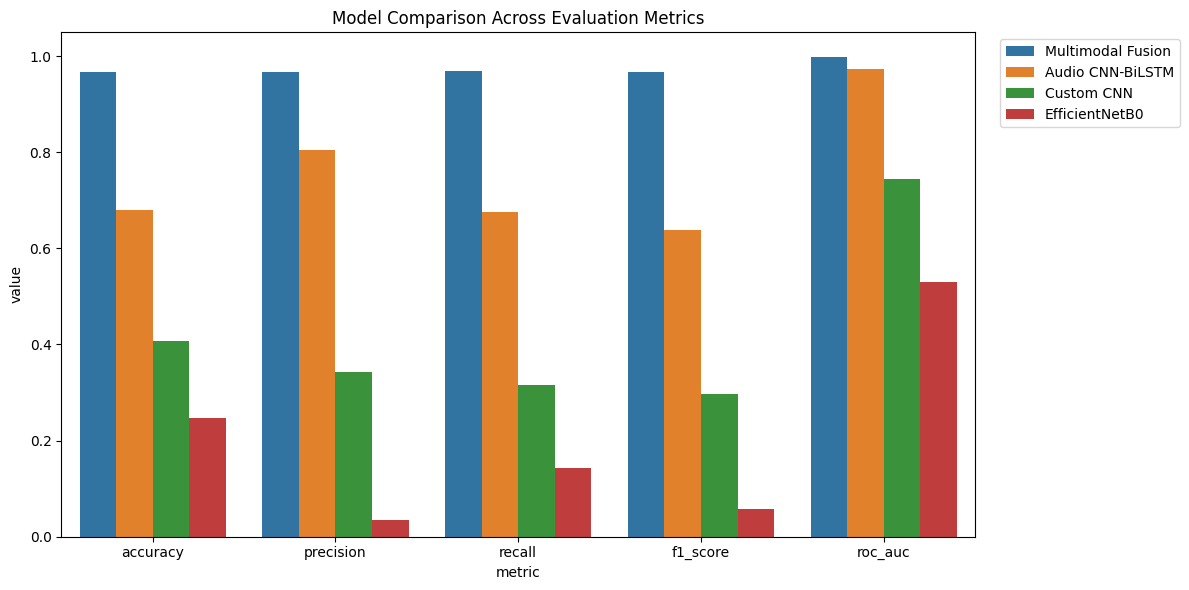


Best-performing model (by F1-score): Multimodal Fusion (F1 = 0.9681, Accuracy = 0.9682)
Multimodal Fusion improved over the Audio-only unimodal baseline on the shared binary task (ΔF1 = +0.3293).


In [34]:
if results_summary:
    comparison_df = pd.DataFrame(results_summary)
    comparison_df = comparison_df[["model", "accuracy", "precision", "recall",
                                    "f1_score", "roc_auc", "inference_time_sec", "n_params"]]
    comparison_df = comparison_df.sort_values(by="f1_score", ascending=False).reset_index(drop=True)

    print("Model Comparison Table:\n")
    print(comparison_df.to_string(index=False))

    # ---- Grouped bar chart across core metrics ----
    metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
    plot_df = comparison_df.melt(id_vars="model", value_vars=metrics_to_plot,
                                  var_name="metric", value_name="value")

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_df, x="metric", y="value", hue="model")
    plt.title("Model Comparison Across Evaluation Metrics")
    plt.ylim(0, 1.05)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # ---- Best model identification ----
    best_row = comparison_df.iloc[0]
    print(f"\nBest-performing model (by F1-score): {best_row['model']} "
          f"(F1 = {best_row['f1_score']:.4f}, Accuracy = {best_row['accuracy']:.4f})")

    if "Multimodal Fusion" in comparison_df['model'].values and "Audio CNN-BiLSTM" in comparison_df['model'].values:
        fusion_f1 = comparison_df.loc[comparison_df['model'] == "Multimodal Fusion", "f1_score"].values[0]
        audio_f1 = comparison_df.loc[comparison_df['model'] == "Audio CNN-BiLSTM", "f1_score"].values[0]
        delta = fusion_f1 - audio_f1
        direction = "improved over" if delta > 0 else "did not improve over"
        print(f"Multimodal Fusion {direction} the Audio-only unimodal baseline on the shared binary task "
              f"(ΔF1 = {delta:+.4f}).")
else:
    print("No results available for comparison - ensure at least one model was trained successfully.")
